# Phase 4 Memory Comparison

Colab notebook to compare the memory strategies using an already trained classifier and visualize the best memory method.


In [6]:
!pip install tensorflow pandas numpy scikit-learn networkx tqdm matplotlib seaborn -q

import os
import subprocess
import sys
from pathlib import Path

from google.colab import drive

drive.mount('/content/drive', force_remount=False)

repo_path = Path('/content/AI_Agentic_DL')
branch_name = 'final-pipeline-integration'
if not repo_path.exists():
    !git clone https://github.com/Lawapaul/AI_Agentic_DL.git /content/AI_Agentic_DL

subprocess.run(['git', '-C', str(repo_path), 'fetch', 'origin'], check=True)
subprocess.run(['git', '-C', str(repo_path), 'checkout', branch_name], check=True)
subprocess.run(['git', '-C', str(repo_path), 'pull', 'origin', branch_name], check=True)

if str(repo_path) not in sys.path:
    sys.path.insert(0, str(repo_path))

print('Repo path:', repo_path)
print('Branch:', branch_name)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Repo path: /content/AI_Agentic_DL
Branch: final-pipeline-integration


In [7]:
from pathlib import Path
import os

processed_candidates = [
    Path('/content/drive/MyDrive/Deep Learning Project/AI Agentic/data/processed'),
    Path('/content/drive/MyDrive/AI Agentic/data/processed'),
    Path('/content/AI_Agentic_DL/data/processed'),
]

required = ['X_train.npy', 'X_test.npy', 'y_train.npy', 'y_test.npy']

processed_path = next(
    (str(path) for path in processed_candidates if path.exists() and all((path / name).exists() for name in required)),
    None,
)

if processed_path is None:
    raise FileNotFoundError(f'Could not find processed .npy folder in: {processed_candidates}')

print('processed_path =', processed_path)


processed_path = /content/drive/MyDrive/Deep Learning Project/AI Agentic/data/processed


In [8]:
from pathlib import Path
import os

base_candidates = [
    Path('/content/drive/MyDrive/Deep Learning Project/AI Agentic'),
    Path('/content/drive/MyDrive/AI Agentic'),
    Path('/content/AI_Agentic_DL'),
]
repo_base = next((path for path in base_candidates if path.exists()), None)
if repo_base is None:
    raise FileNotFoundError(f'No project directory found in: {base_candidates}')

model_candidates = [
    repo_base / 'saved_models' / 'hybrid_cnn_lstm_full_2_2m.keras',
    repo_base / 'saved_models' / 'hybrid_cnn_lstm_500k.keras',
    Path('/content/AI_Agentic_DL/saved_models/hybrid_cnn_lstm_full_2_2m.keras'),
    Path('/content/AI_Agentic_DL/saved_models/hybrid_cnn_lstm_500k.keras'),
]
model_path = next((str(path) for path in model_candidates if path.exists()), None)
if model_path is None:
    raise FileNotFoundError(f'No pretrained model found in: {model_candidates}')

output_csv = str(repo_base / 'experiments' / 'results' / 'memory_phase_resultds.csv')
os.makedirs(os.path.dirname(output_csv), exist_ok=True)

print('Model path:', model_path)
print('Output CSV:', output_csv)


Model path: /content/drive/MyDrive/Deep Learning Project/AI Agentic/saved_models/hybrid_cnn_lstm_full_2_2m.keras
Output CSV: /content/drive/MyDrive/Deep Learning Project/AI Agentic/experiments/results/memory_phase_resultds.csv


In [9]:
!cd /content/AI_Agentic_DL && python experiments/phase4_memory_pipeline.py   --processed_path "{processed_path}"   --model_path "{model_path}"   --compare_all   --batch_size 128   --top_k 5   --fg_bank_limit 2000   --train_limit 5000   --test_limit 1000   --output "{output_csv}"


2026-03-30 17:02:30.493223: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-30 17:02:30.499838: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-30 17:02:30.529956: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774890150.583927   26100 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774890150.600066   26100 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774890150.641552   26100 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [10]:
import pandas as pd

results_df = pd.read_csv(output_csv)
results_df = results_df.sort_values('top1_retrieval_accuracy', ascending=False).reset_index(drop=True)
display(results_df)
print('Saved results CSV:', output_csv)


,strategy,top1_retrieval_accuracy,top5_retrieval_accuracy,class_purity,retrieval_entropy,avg_cosine_similarity,retrieval_time_sec,memory_bank_size
0,GraphAwareMemory,0.980,0.989,0.9820,0.013968,0.975599,0.001595,2000.0
1,EmbeddingKNN,0.978,0.998,0.9786,0.038589,0.975656,0.000658,2000.0
2,CombinedMemory,0.978,0.997,0.9748,0.043119,0.949452,0.001026,2000.0
3,PrototypeMemory,0.974,1.000,0.2000,2.321928,0.435627,0.000064,10.0
4,FGKNN,0.962,0.989,0.9374,0.116402,0.941452,0.000473,2000.0
5,NoMemory,0.000,0.000,0.0000,0.000000,0.000000,0.000003,0.0


Saved results CSV: /content/drive/MyDrive/Deep Learning Project/AI Agentic/experiments/results/memory_phase_resultds.csv


/tmp/ipykernel_21841/101405799.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='strategy', y='top1_retrieval_accuracy', palette='viridis', ax=axes[0])
/tmp/ipykernel_21841/101405799.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='strategy', y='retrieval_time_sec', palette='mako', ax=axes[1])
/tmp/ipykernel_21841/101405799.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='strategy', y='memory_bank_size', palette='rocket', ax=axes[2])


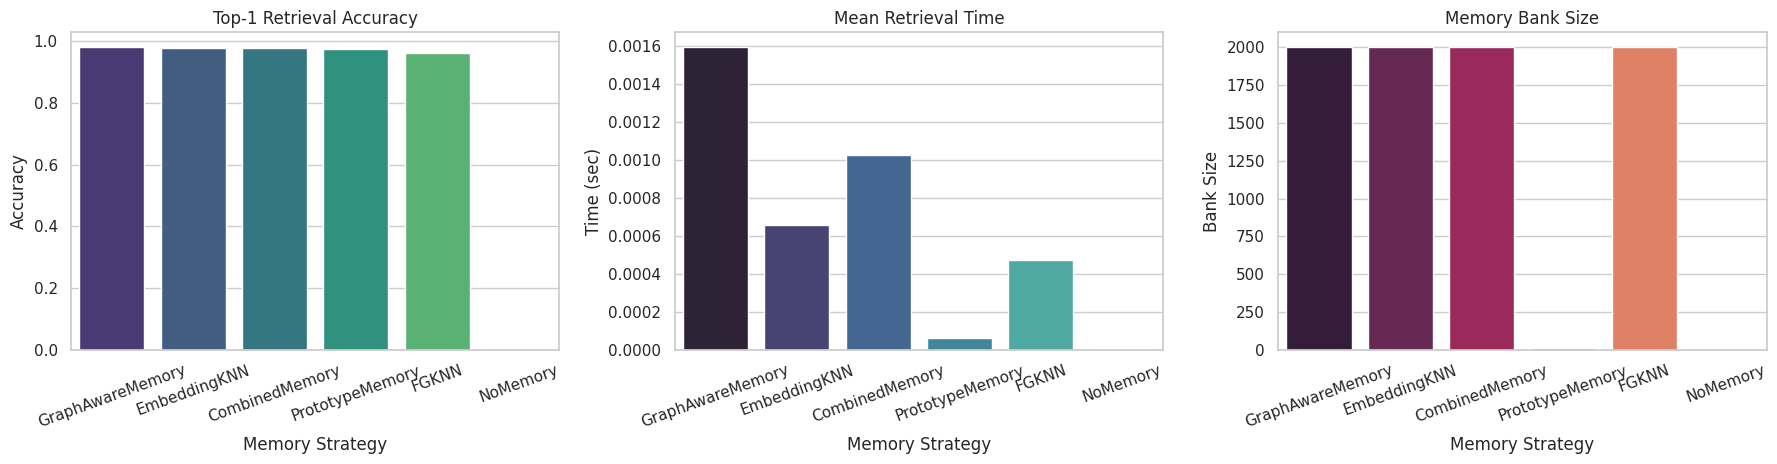

Saved memory comparison plots: /content/drive/MyDrive/Deep Learning Project/AI Agentic/experiments/results/memory_phase_resultds_plots.png


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

sns.barplot(data=results_df, x='strategy', y='top1_retrieval_accuracy', palette='viridis', ax=axes[0])
axes[0].set_title('Top-1 Retrieval Accuracy')
axes[0].set_xlabel('Memory Strategy')
axes[0].set_ylabel('Accuracy')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=results_df, x='strategy', y='retrieval_time_sec', palette='mako', ax=axes[1])
axes[1].set_title('Mean Retrieval Time')
axes[1].set_xlabel('Memory Strategy')
axes[1].set_ylabel('Time (sec)')
axes[1].tick_params(axis='x', rotation=20)

sns.barplot(data=results_df, x='strategy', y='memory_bank_size', palette='rocket', ax=axes[2])
axes[2].set_title('Memory Bank Size')
axes[2].set_xlabel('Memory Strategy')
axes[2].set_ylabel('Bank Size')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

plot_path = os.path.join(os.path.dirname(output_csv), 'memory_phase_resultds_plots.png')
fig.savefig(plot_path, dpi=200, bbox_inches='tight')
print('Saved memory comparison plots:', plot_path)
